<a href="https://colab.research.google.com/github/suresh-vlsi/machine-learning-algorithms/blob/main/01_linear_regression/notebooks/Linear_Regression_Optimization_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interactive Linear Regression & Optimization Playground

This notebook is an interactive extension of the from-scratch Linear Regression project.

Use the controls to change **both the dataset and the optimization algorithm** without editing Python code.

### Dataset controls
- Dataset type
- Number of samples
- True slope and intercept
- Noise level
- Random seed
- Optional outliers

### Optimization controls
- Vanilla Gradient Descent
- Momentum
- Nesterov
- AdaGrad
- RMSProp
- Adam
- Learning rate
- Iterations
- Momentum / Adam beta parameters
- Feature standardization


## 0. Setup

This notebook is self-contained and designed for Google Colab. It uses NumPy and Matplotlib only.

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=6, suppress=True)
print("Environment ready.")

Environment ready.


## 1. Dataset and linear model

$$\hat y_i=b_0+b_1x_i$$

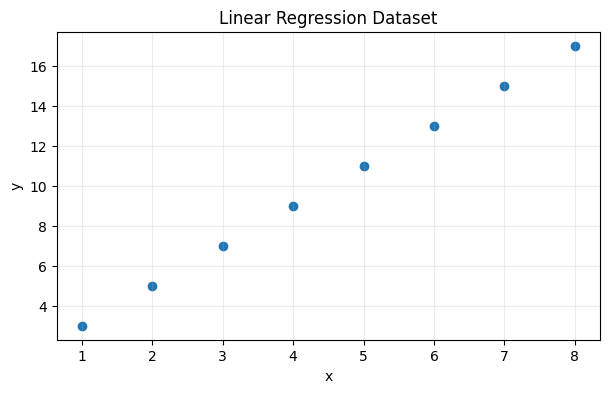

In [67]:
x=np.array([1.,2.,3.,4.,5.,6.,7.,8.])
y=np.array([3.,5.,7.,9.,11.,13.,15.,17.])

def predict(theta, xdata=x):
    return theta[0] + theta[1]*xdata

def mse(theta, xdata=x, ydata=y):
    return np.mean((predict(theta,xdata)-ydata)**2)

plt.figure(figsize=(7,4))
plt.scatter(x,y)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Linear Regression Dataset"); plt.grid(True,alpha=.25); plt.show()

## 2. Mean Squared Error and analytical gradient

$$J(\theta)=\frac1n\sum_i(\hat y_i-y_i)^2$$

$$\frac{\partial J}{\partial b_0}=\frac2n\sum_i(\hat y_i-y_i),\qquad
\frac{\partial J}{\partial b_1}=\frac2n\sum_i(\hat y_i-y_i)x_i$$

In [68]:
def gradient(theta, xdata=x, ydata=y):
    e=predict(theta,xdata)-ydata
    return np.array([2*np.mean(e), 2*np.mean(e*xdata)])

print("Initial loss:", mse(np.zeros(2)))
print("Initial gradient:", gradient(np.zeros(2)))

Initial loss: 121.0
Initial gradient: [ -20. -111.]


## 3. Gradient Descent

$$\theta_{t+1}=\theta_t-\alpha\nabla J(\theta_t)$$

In [69]:
def gradient_descent(alpha=.01, iterations=100, xdata=x, ydata=y):
    theta=np.zeros(2); losses=[mse(theta,xdata,ydata)]; history=[theta.copy()]
    for _ in range(iterations):
        theta -= alpha*gradient(theta,xdata,ydata)
        losses.append(mse(theta,xdata,ydata)); history.append(theta.copy())
    return theta,np.array(losses),np.array(history)

theta_gd,loss_gd,hist_gd=gradient_descent()
print("Final parameters:",theta_gd)
print("Final MSE:",loss_gd[-1])

Final parameters: [0.581387 2.074456]
Final MSE: 0.036086804630962914


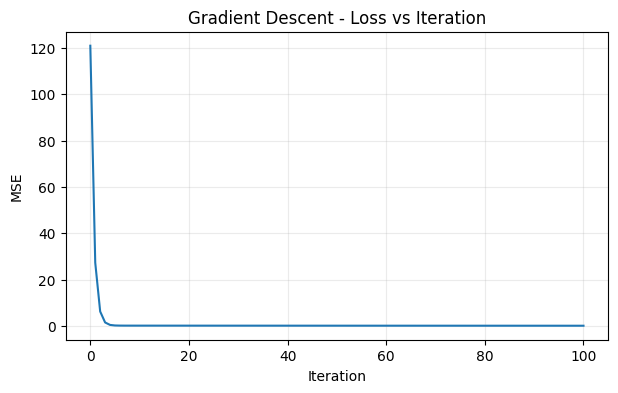

In [70]:
plt.figure(figsize=(7,4)); plt.plot(loss_gd); plt.xlabel("Iteration"); plt.ylabel("MSE"); plt.title("Gradient Descent - Loss vs Iteration"); plt.grid(True,alpha=.25); plt.show()

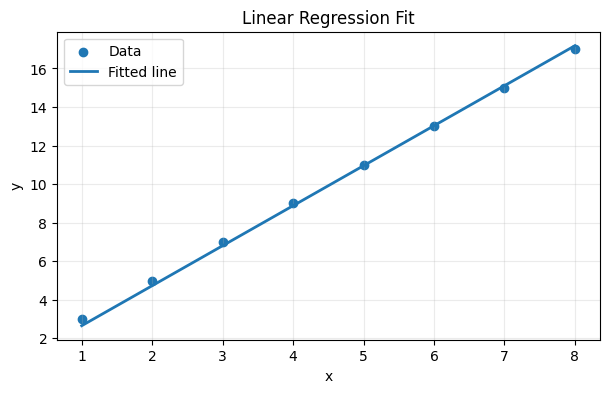

In [71]:
xx=np.linspace(x.min(),x.max(),200)
plt.figure(figsize=(7,4)); plt.scatter(x,y,label="Data"); plt.plot(xx,predict(theta_gd,xx),label="Fitted line",linewidth=2); plt.xlabel("x"); plt.ylabel("y"); plt.title("Linear Regression Fit"); plt.grid(True,alpha=.25); plt.legend(); plt.show()

## 4. 3D loss surface and optimization trajectory

Because there are only two parameters, the full objective surface can be visualized.

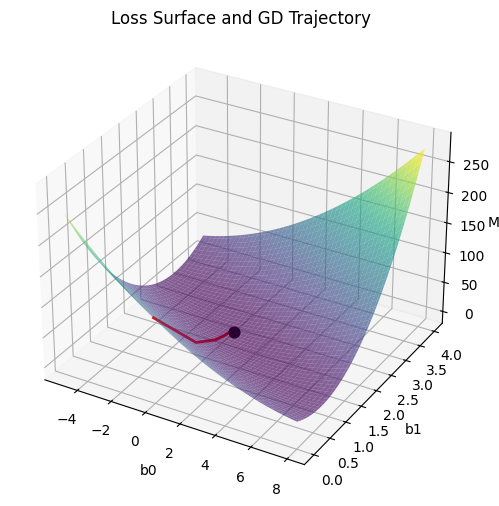

In [72]:
b0=np.linspace(-5,8,100); b1=np.linspace(0,4,100); B0,B1=np.meshgrid(b0,b1)
Z=np.empty_like(B0)
for i in range(B0.shape[0]):
    for j in range(B0.shape[1]): Z[i,j]=mse([B0[i,j],B1[i,j]])
fig=plt.figure(figsize=(9,6)); ax=fig.add_subplot(111,projection="3d")
ax.plot_surface(B0,B1,Z,cmap="viridis",alpha=.65)
ax.plot(hist_gd[:,0],hist_gd[:,1],[mse(t) for t in hist_gd],color="red",linewidth=2)
ax.scatter(theta_gd[0],theta_gd[1],mse(theta_gd),color="black",s=60)
ax.set_xlabel("b0"); ax.set_ylabel("b1"); ax.set_zlabel("MSE"); ax.set_title("Loss Surface and GD Trajectory"); plt.show()

## 5. Gradient direction and numerical gradient checking

The gradient points uphill; $-\nabla J$ points downhill.

Finite difference check:

$$\frac{\partial J}{\partial\theta_j}\approx\frac{J(\theta+\epsilon e_j)-J(\theta-\epsilon e_j)}{2\epsilon}.$$

In [73]:
theta_test=np.array([1.,1.]); g=gradient(theta_test)
print("Gradient:",g,"\nNegative gradient:",-g)

def numerical_gradient(theta,eps=1e-6):
    out=np.zeros_like(theta)
    for j in range(len(theta)):
        p=theta.copy(); m=theta.copy(); p[j]+=eps; m[j]-=eps
        out[j]=(mse(p)-mse(m))/(2*eps)
    return out

print("Analytical:",gradient(theta_test))
print("Numerical :",numerical_gradient(theta_test))

Gradient: [ -9. -51.] 
Negative gradient: [ 9. 51.]
Analytical: [ -9. -51.]
Numerical : [ -9. -51.]


## 6. Learning rate and stability boundary

For this quadratic problem,

$$0<\alpha<\frac{2}{\lambda_{\max}}.$$

In [74]:
H=np.array([[2.,7.],[7.,30.3333333333333]])
evals=np.linalg.eigvalsh(H); lam=evals.max(); limit=2/lam
print("Hessian=\n",H)
print("Eigenvalues:",evals)
print("Theoretical stability limit:",limit)

Hessian=
 [[ 2.        7.      ]
 [ 7.       30.333333]]
Eigenvalues: [ 0.364944 31.968389]
Theoretical stability limit: 0.06256180030942518


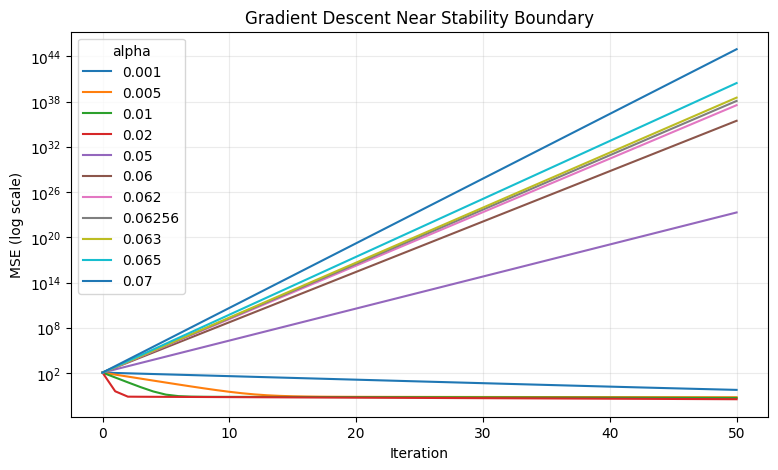

In [75]:
rates=[.001,.005,.01,.02,.05,.06,.062,.06256,.063,.065,.07]
plt.figure(figsize=(9,5))
for a in rates:
    _,L,_=gradient_descent(alpha=a,iterations=50); plt.plot(L,label=str(a))
plt.yscale("log"); plt.xlabel("Iteration"); plt.ylabel("MSE (log scale)"); plt.title("Gradient Descent Near Stability Boundary"); plt.grid(True,alpha=.25); plt.legend(title="alpha"); plt.show()

## 7. Feature scaling and parameter trajectory

Standardization:

$$x'=(x-\mu)/\sigma.$$

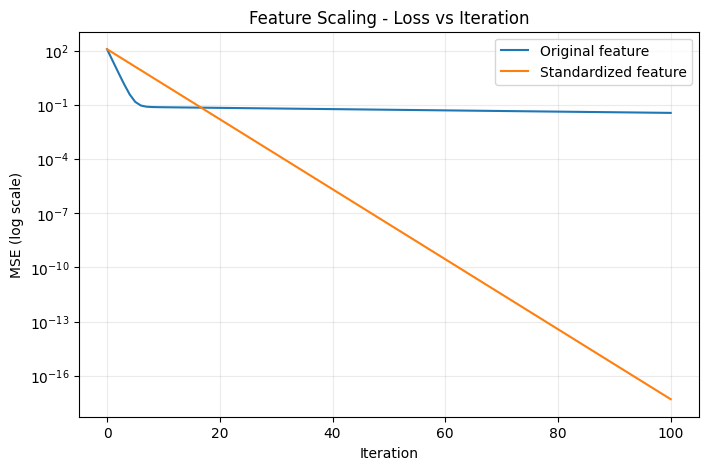

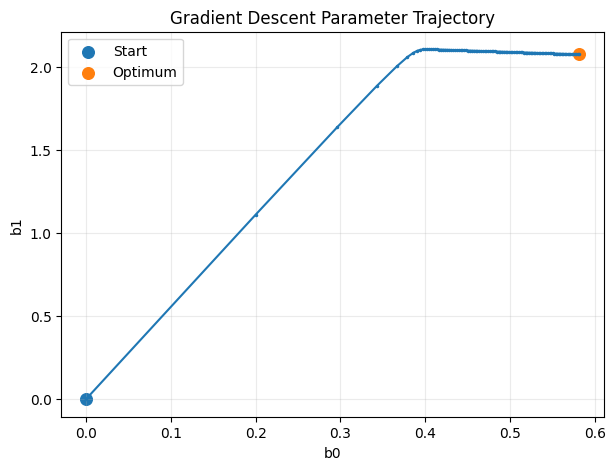

In [76]:
xs=(x-x.mean())/x.std()
def ps(t): return t[0]+t[1]*xs
def ms(t): return np.mean((ps(t)-y)**2)
def gs(t):
    e=ps(t)-y; return np.array([2*np.mean(e),2*np.mean(e*xs)])
def gd_scaled(alpha=.1,iterations=100):
    t=np.zeros(2); L=[ms(t)]; Hs=[t.copy()]
    for _ in range(iterations): t-=alpha*gs(t); L.append(ms(t)); Hs.append(t.copy())
    return t,np.array(L),np.array(Hs)

_,Lscaled,Hscaled=gd_scaled()
plt.figure(figsize=(8,5)); plt.plot(loss_gd,label="Original feature"); plt.plot(Lscaled,label="Standardized feature"); plt.yscale("log"); plt.xlabel("Iteration"); plt.ylabel("MSE (log scale)"); plt.title("Feature Scaling - Loss vs Iteration"); plt.grid(True,alpha=.25); plt.legend(); plt.show()

plt.figure(figsize=(7,5)); plt.plot(hist_gd[:,0],hist_gd[:,1],marker=".",markersize=3); plt.scatter(hist_gd[0,0],hist_gd[0,1],s=70,label="Start"); plt.scatter(theta_gd[0],theta_gd[1],s=70,label="Optimum"); plt.xlabel("b0"); plt.ylabel("b1"); plt.title("Gradient Descent Parameter Trajectory"); plt.grid(True,alpha=.25); plt.legend(); plt.show()

## 8. Momentum and Nesterov

Momentum:

$$v_t=\beta v_{t-1}-\alpha g_t,\qquad\theta_{t+1}=\theta_t+v_t.$$

Nesterov evaluates the gradient at a look-ahead point:

$$\theta_{lookahead}=\theta_t+\beta v_t.$$

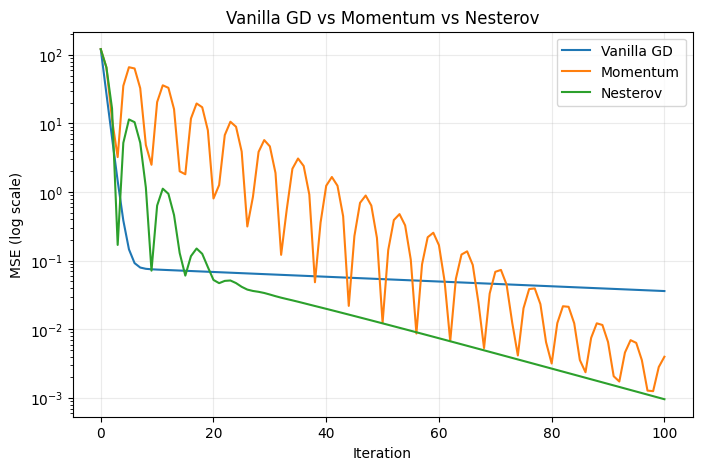

In [77]:
def momentum(alpha=.005,beta=.9,iterations=100):
    t=np.zeros(2); v=np.zeros(2); L=[mse(t)]; H=[t.copy()]
    for _ in range(iterations):
        v=beta*v-alpha*gradient(t); t+=v; L.append(mse(t)); H.append(t.copy())
    return t,np.array(L),np.array(H)

def nesterov(alpha=.005,beta=.9,iterations=100):
    t=np.zeros(2); v=np.zeros(2); L=[mse(t)]; H=[t.copy()]
    for _ in range(iterations):
        g=gradient(t+beta*v); v=beta*v-alpha*g; t+=v; L.append(mse(t)); H.append(t.copy())
    return t,np.array(L),np.array(H)

_,Lm,_=momentum(); _,Ln,_=nesterov()
plt.figure(figsize=(8,5)); plt.plot(loss_gd,label="Vanilla GD"); plt.plot(Lm,label="Momentum"); plt.plot(Ln,label="Nesterov"); plt.yscale("log"); plt.xlabel("Iteration"); plt.ylabel("MSE (log scale)"); plt.title("Vanilla GD vs Momentum vs Nesterov"); plt.grid(True,alpha=.25); plt.legend(); plt.show()

In [ ]:
plt.figure(figsize=(8,5))
for beta in [0,.5,.9,.99]:
    _,L,_=momentum(beta=beta); plt.plot(L,label=f"beta={beta}")
plt.yscale("log"); plt.xlabel("Iteration"); plt.ylabel("MSE (log scale)"); plt.title("Momentum - Effect of beta"); plt.grid(True,alpha=.25); plt.legend(); plt.show()

## 9. AdaGrad, RMSProp, and Adam

AdaGrad:

$$G_t=G_{t-1}+g_t^2,\qquad\theta_{t+1}=\theta_t-\alpha\frac{g_t}{\sqrt{G_t}+\epsilon}.$$

RMSProp:

$$S_t=\beta S_{t-1}+(1-\beta)g_t^2.$$

Adam:

$$m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,$$
$$v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2,$$
$$\hat m_t=\frac{m_t}{1-\beta_1^t},\quad \hat v_t=\frac{v_t}{1-\beta_2^t}.$$

In [ ]:
def adagrad(alpha=.5,eps=1e-8,iters=100):
    t=np.zeros(2); G=np.zeros(2); L=[mse(t)]
    for _ in range(iters):
        g=gradient(t); G+=g*g; t-=alpha*g/(np.sqrt(G)+eps); L.append(mse(t))
    return t,np.array(L)

def rmsprop(alpha=.05,beta=.9,eps=1e-8,iters=100):
    t=np.zeros(2); S=np.zeros(2); L=[mse(t)]
    for _ in range(iters):
        g=gradient(t); S=beta*S+(1-beta)*g*g; t-=alpha*g/(np.sqrt(S)+eps); L.append(mse(t))
    return t,np.array(L)

def adam(alpha=.05,beta1=.9,beta2=.999,eps=1e-8,iters=100):
    t=np.zeros(2); m=np.zeros(2); v=np.zeros(2); L=[mse(t)]
    for k in range(1,iters+1):
        g=gradient(t); m=beta1*m+(1-beta1)*g; v=beta2*v+(1-beta2)*g*g
        mh=m/(1-beta1**k); vh=v/(1-beta2**k); t-=alpha*mh/(np.sqrt(vh)+eps); L.append(mse(t))
    return t,np.array(L)

_,La=adagrad(); _,Lr=rmsprop(); _,Lad=adam()
plt.figure(figsize=(9,5)); plt.plot(La,label="AdaGrad"); plt.plot(Lr,label="RMSProp"); plt.plot(Lad,label="Adam"); plt.yscale("log"); plt.xlabel("Iteration"); plt.ylabel("MSE (log scale)"); plt.title("Adaptive Optimizers"); plt.grid(True,alpha=.25); plt.legend(); plt.show()

## 10. Final optimizer comparison

The exact learning rates below are demonstration settings, not universal recommendations.

In [ ]:
optimizers={"Vanilla GD":loss_gd,"Momentum":Lm,"Nesterov":Ln,"AdaGrad":La,"RMSProp":Lr,"Adam":Lad}
plt.figure(figsize=(10,6))
for name,L in optimizers.items(): plt.plot(L,label=name)
plt.yscale("log"); plt.xlabel("Iteration"); plt.ylabel("MSE (log scale)"); plt.title("Optimization Algorithm Comparison"); plt.grid(True,alpha=.25); plt.legend(); plt.show()
print(f"{'Optimizer':<15}{'Final MSE':>16}")
print('-'*31)
for name,L in optimizers.items(): print(f"{name:<15}{L[-1]:>16.8e}")

## 11. Project / GitHub / Colab workflow

Recommended repository location:

```text
machine-learning-algorithms/
└── 01_linear_regression/
    └── notebooks/
        └── Linear_Regression_Optimization_Demo.ipynb
```

After committing this notebook to GitHub, it can be opened directly in Google Colab. Add an **Open in Colab** badge to the repository README so visitors can launch the demo with one click.

**Run:** `Runtime → Run all`.

**Collaboration:** use the Colab **Share** button to give others viewer, commenter, or editor access. The notebook content, code, text, saved outputs, and comments can be shared; the temporary runtime itself is not shared.


# 🎛️ Interactive Optimization Playground

This section turns the project into an interactive experiment. Change the controls and press **Run experiment** to see how the optimizer, learning rate, momentum, number of iterations, and feature scaling affect convergence.

Try changing **one parameter at a time** so the effect is easy to interpret.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Main experiment controls
optimizer_dd = widgets.Dropdown(
    options=['Vanilla GD', 'Momentum', 'Nesterov', 'AdaGrad', 'RMSProp', 'Adam'],
    value='Vanilla GD',
    description='Optimizer:',
    layout=widgets.Layout(width='360px')
)

alpha_slider = widgets.FloatSlider(
    value=0.01, min=0.0001, max=0.10, step=0.0001,
    description='Learning rate:', readout_format='.4f',
    continuous_update=False, layout=widgets.Layout(width='500px')
)

iterations_slider = widgets.IntSlider(
    value=100, min=10, max=500, step=10,
    description='Iterations:', continuous_update=False,
    layout=widgets.Layout(width='500px')
)

beta1_slider = widgets.FloatSlider(
    value=0.9, min=0.0, max=0.99, step=0.01,
    description='β / β₁:', readout_format='.2f',
    continuous_update=False, layout=widgets.Layout(width='500px')
)

beta2_slider = widgets.FloatSlider(
    value=0.999, min=0.90, max=0.9999, step=0.001,
    description='β₂:', readout_format='.3f',
    continuous_update=False, layout=widgets.Layout(width='500px')
)

scaling_check = widgets.Checkbox(
    value=False, description='Standardize feature x'
)

run_button = widgets.Button(
    description='▶ Run experiment', button_style='primary',
    layout=widgets.Layout(width='180px', height='40px')
)

output = widgets.Output()

controls = widgets.VBox([
    optimizer_dd,
    alpha_slider,
    iterations_slider,
    beta1_slider,
    beta2_slider,
    scaling_check,
    run_button
])

display(controls, output)


In [ ]:
def interactive_run(optimizer, alpha, iterations, beta1, beta2, scaled):
    if scaled:
        x_data = (x - x.mean()) / x.std()
    else:
        x_data = x.copy()

    def pred(theta):
        return theta[0] + theta[1] * x_data

    def loss(theta):
        return np.mean((pred(theta) - y) ** 2)

    def grad(theta):
        error = pred(theta) - y
        return np.array([2 * np.mean(error), 2 * np.mean(error * x_data)])

    theta = np.zeros(2)
    velocity = np.zeros(2)
    accumulator = np.zeros(2)
    m = np.zeros(2)
    v = np.zeros(2)

    losses = [loss(theta)]
    history = [theta.copy()]
    eps = 1e-8

    for t in range(1, iterations + 1):
        if optimizer == 'Vanilla GD':
            g = grad(theta)
            theta -= alpha * g

        elif optimizer == 'Momentum':
            g = grad(theta)
            velocity = beta1 * velocity - alpha * g
            theta += velocity

        elif optimizer == 'Nesterov':
            lookahead = theta + beta1 * velocity
            g = grad(lookahead)
            velocity = beta1 * velocity - alpha * g
            theta += velocity

        elif optimizer == 'AdaGrad':
            g = grad(theta)
            accumulator += g ** 2
            theta -= alpha * g / (np.sqrt(accumulator) + eps)

        elif optimizer == 'RMSProp':
            g = grad(theta)
            accumulator = beta1 * accumulator + (1 - beta1) * g ** 2
            theta -= alpha * g / (np.sqrt(accumulator) + eps)

        elif optimizer == 'Adam':
            g = grad(theta)
            m = beta1 * m + (1 - beta1) * g
            v = beta2 * v + (1 - beta2) * g ** 2
            m_hat = m / (1 - beta1 ** t)
            v_hat = v / (1 - beta2 ** t)
            theta -= alpha * m_hat / (np.sqrt(v_hat) + eps)

        current_loss = loss(theta)
        losses.append(current_loss)
        history.append(theta.copy())

        # Stop cleanly if a deliberately unstable setting overflows.
        if not np.isfinite(current_loss):
            break

    losses = np.asarray(losses)
    history = np.asarray(history)

    with output:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

        axes[0].plot(losses, linewidth=2)
        axes[0].set_yscale('log')
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('MSE (log scale)')
        axes[0].set_title(f'{optimizer}: Loss vs Iteration')
        axes[0].grid(True, alpha=0.25)

        axes[1].plot(history[:, 0], history[:, 1], linewidth=2)
        axes[1].scatter(history[0, 0], history[0, 1], s=60, label='Start')
        if np.isfinite(losses[-1]):
            axes[1].scatter(history[-1, 0], history[-1, 1], s=60, label='Final')
        axes[1].set_xlabel('b₀')
        axes[1].set_ylabel('b₁')
        axes[1].set_title('Parameter Trajectory')
        axes[1].grid(True, alpha=0.25)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        print(f'Optimizer: {optimizer}')
        print(f'Learning rate: {alpha:.4g}')
        print(f'Iterations completed: {len(losses)-1}')
        print(f'Feature scaling: {"ON" if scaled else "OFF"}')
        print(f'Final parameters: {history[-1]}')
        print(f'Final MSE: {losses[-1]:.8e}')
        if not np.isfinite(losses[-1]):
            print('Result became unstable/non-finite. Try a smaller learning rate.')

def on_run_clicked(_):
    interactive_run(
        optimizer_dd.value,
        alpha_slider.value,
        iterations_slider.value,
        beta1_slider.value,
        beta2_slider.value,
        scaling_check.value
    )

run_button.on_click(on_run_clicked)

# Show an initial experiment automatically.
interactive_run(
    optimizer_dd.value,
    alpha_slider.value,
    iterations_slider.value,
    beta1_slider.value,
    beta2_slider.value,
    scaling_check.value
)



## 🎯 Suggested experiments

**Experiment A — Learning rate:** choose `Vanilla GD` and try $\alpha=0.001$, $0.01$, $0.05$, and values near the theoretical stability boundary.

**Experiment B — Momentum:** choose `Momentum` and compare $\beta=0$, $0.5$, $0.9$, and $0.99$.

**Experiment C — Nesterov:** keep the same learning rate and compare `Momentum` with `Nesterov`.

**Experiment D — Feature scaling:** turn on **Standardize feature x** and compare the parameter trajectory and convergence speed.

**Experiment E — Adaptive methods:** compare `AdaGrad`, `RMSProp`, and `Adam` while changing the learning rate.

This makes the notebook a genuine interactive optimization laboratory rather than a static collection of plots.


## Dataset + Optimizer Playground

Change the dataset and optimization settings below, then click **Run experiment**. The plots and numerical results update together.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

def make_dataset(kind, n, slope, intercept, noise, seed, outliers, n_outliers):
    rng = np.random.default_rng(seed)
    x = np.linspace(-5, 5, n)
    if kind == 'Two-regime linear':
        y_true = np.where(x < 0, slope*x + intercept, 0.55*slope*x + intercept)
    elif kind == 'Nearly flat':
        y_true = 0.15*x + intercept
    else:
        y_true = slope*x + intercept
    y = y_true + rng.normal(0, noise, n)
    if outliers and n_outliers > 0:
        count=min(n_outliers,n); idx=rng.choice(n,size=count,replace=False)
        scale=max(noise,0.5)
        y[idx] += rng.choice([-1,1],size=count)*rng.uniform(3*scale,8*scale,size=count)
    return x,y,y_true

def standardize_x(x):
    mu=np.mean(x); sigma=np.std(x)
    return (x-mu)/sigma,mu,sigma

def loss_and_grad(theta,x,y):
    w,b=theta; err=w*x+b-y
    return np.mean(err**2), np.array([2*np.mean(err*x),2*np.mean(err)])

def optimize(x,y,optimizer,alpha,iterations,beta,beta2):
    theta=np.zeros(2); m=np.zeros(2); v=np.zeros(2); r=np.zeros(2); eps=1e-8
    losses=[]; trajectory=[]
    for t in range(1,iterations+1):
        if optimizer=='Nesterov':
            look=theta-beta*m; _,g=loss_and_grad(look,x,y); m=beta*m+g; theta-=alpha*m
        else:
            _,g=loss_and_grad(theta,x,y)
            if optimizer=='Vanilla GD': theta-=alpha*g
            elif optimizer=='Momentum': m=beta*m+g; theta-=alpha*m
            elif optimizer=='AdaGrad': r+=g*g; theta-=alpha*g/(np.sqrt(r)+eps)
            elif optimizer=='RMSProp': r=beta2*r+(1-beta2)*g*g; theta-=alpha*g/(np.sqrt(r)+eps)
            elif optimizer=='Adam':
                m=beta*m+(1-beta)*g; v=beta2*v+(1-beta2)*g*g
                theta-=alpha*(m/(1-beta**t))/(np.sqrt(v/(1-beta2**t))+eps)
        loss,_=loss_and_grad(theta,x,y); losses.append(loss); trajectory.append(theta.copy())
        if not np.isfinite(loss) or loss>1e100: break
    return theta,np.array(losses),np.array(trajectory)


In [ ]:
dataset_type=widgets.Dropdown(options=['Linear','Linear + Noise','Two-regime linear','Nearly flat'],value='Linear + Noise',description='Dataset:')
n_samples=widgets.IntSlider(value=50,min=10,max=300,step=10,description='Samples:')
true_slope=widgets.FloatSlider(value=2.0,min=-5,max=5,step=0.1,description='Slope:')
true_intercept=widgets.FloatSlider(value=1.0,min=-10,max=10,step=0.5,description='Intercept:')
noise_level=widgets.FloatSlider(value=0.5,min=0,max=5,step=0.1,description='Noise:')
seed=widgets.IntSlider(value=42,min=0,max=1000,description='Seed:')
add_outliers=widgets.Checkbox(value=False,description='Add outliers')
n_outliers=widgets.IntSlider(value=3,min=0,max=30,description='Outliers:')
optimizer=widgets.Dropdown(options=['Vanilla GD','Momentum','Nesterov','AdaGrad','RMSProp','Adam'],value='Adam',description='Optimizer:')
alpha=widgets.FloatLogSlider(value=0.01,base=10,min=-4,max=0,step=0.05,description='LR α:')
iterations=widgets.IntSlider(value=500,min=10,max=3000,step=10,description='Iterations:')
beta=widgets.FloatSlider(value=0.9,min=0,max=0.99,step=0.01,description='β / β₁:')
beta2=widgets.FloatSlider(value=0.999,min=0.9,max=0.9999,step=0.0001,description='β₂:')
standardize=widgets.Checkbox(value=False,description='Standardize feature')
run_button=widgets.Button(description='▶ Run experiment',button_style='success')
compare_button=widgets.Button(description='Compare all optimizers',button_style='info')
output=widgets.Output()
dataset_box=widgets.VBox([widgets.HTML('<h3>Dataset controls</h3>'),dataset_type,n_samples,true_slope,true_intercept,noise_level,seed,add_outliers,n_outliers])
optimizer_box=widgets.VBox([widgets.HTML('<h3>Optimization controls</h3>'),optimizer,alpha,iterations,beta,beta2,standardize])
display(widgets.HBox([dataset_box,optimizer_box])); display(widgets.HBox([run_button,compare_button])); display(output)


In [ ]:
def get_problem():
    x,y,y_true=make_dataset(dataset_type.value,n_samples.value,true_slope.value,true_intercept.value,noise_level.value,seed.value,add_outliers.value,n_outliers.value)
    xu=x.copy(); mu=0.0; sigma=1.0
    if standardize.value: xu,mu,sigma=standardize_x(xu)
    return x,y,y_true,xu,mu,sigma

def run_single(_=None):
    with output:
        clear_output(wait=True)
        x,y,y_true,xu,mu,sigma=get_problem()
        theta,losses,traj=optimize(xu,y,optimizer.value,alpha.value,iterations.value,beta.value,beta2.value)
        w,b=theta; wo=w/sigma; bo=b-w*mu/sigma
        fig=plt.figure(figsize=(16,4.8))
        ax=fig.add_subplot(1,3,1); order=np.argsort(x)
        ax.scatter(x,y,label='Dataset'); ax.plot(x[order],y_true[order],'--',label='Underlying relation'); ax.plot(x[order],wo*x[order]+bo,label='Learned line')
        ax.set_title('Dataset and Regression Fit'); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend(); ax.grid(True,alpha=.25)
        ax=fig.add_subplot(1,3,2); ax.plot(losses); ax.set_yscale('log'); ax.set_title('Loss vs Iteration'); ax.set_xlabel('Iteration'); ax.set_ylabel('MSE (log scale)'); ax.grid(True,alpha=.25)
        ax=fig.add_subplot(1,3,3); ax.plot(traj[:,0],traj[:,1]); ax.scatter(traj[0,0],traj[0,1],label='Start'); ax.scatter(traj[-1,0],traj[-1,1],marker='x',s=80,label='End'); ax.set_title('Parameter Trajectory'); ax.set_xlabel('w'); ax.set_ylabel('b'); ax.legend(); ax.grid(True,alpha=.25)
        plt.tight_layout(); plt.show()
        print('Dataset:',dataset_type.value,'| Samples:',n_samples.value,'| Noise:',noise_level.value,'| Seed:',seed.value)
        print('Optimizer:',optimizer.value); print(f'Learned slope w = {wo:.6f}'); print(f'Learned intercept b = {bo:.6f}'); print(f'Final MSE = {losses[-1]:.8f}'); print(f'Iterations completed = {len(losses)}')

def compare_all(_=None):
    with output:
        clear_output(wait=True); x,y,y_true,xu,mu,sigma=get_problem()
        opts=['Vanilla GD','Momentum','Nesterov','AdaGrad','RMSProp','Adam']; results=[]
        plt.figure(figsize=(9,5.5))
        for opt in opts:
            theta,losses,_=optimize(xu,y,opt,alpha.value,iterations.value,beta.value,beta2.value); plt.plot(losses,label=opt); results.append((opt,losses[-1],len(losses)))
        plt.yscale('log'); plt.xlabel('Iteration'); plt.ylabel('MSE (log scale)'); plt.title('Optimizer Comparison on the Same Dataset'); plt.grid(True,alpha=.25); plt.legend(); plt.show()
        print(f'Dataset: {dataset_type.value} | samples={n_samples.value} | noise={noise_level.value} | seed={seed.value}')
        print(f"{'Optimizer':<14} {'Final MSE':>14} {'Iterations':>12}"); print('-'*42)
        for opt,final_loss,count in results: print(f'{opt:<14} {final_loss:>14.8f} {count:>12}')
run_button.on_click(run_single); compare_button.on_click(compare_all)


## Suggested Interactive Experiments

1. Keep the seed fixed and change **noise** from `0.1` to `3.0`.
2. Keep the dataset fixed and compare **GD, Momentum, Nesterov, and Adam**.
3. Increase samples from `20` to `200`.
4. Turn on **outliers** and observe the effect on ordinary least-squares regression.
5. Compare optimization with and without **feature standardization**.
6. Change the random seed while keeping all other parameters fixed.
7. Try a large learning rate and observe instability or slow/failed convergence.
8. Change the true slope/intercept and verify that the learned parameters follow the generated relationship.
